In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [20]:
# 1. 데이터 불러오기
df = pd.read_csv("affairs.csv")
# 2. 불필요한 index 열 제거
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# 3. 기본 정보 확인
print(df.head())
print(df.info())
print(df.describe())

df.head(5)

   rate_marriage   age  yrs_married  children  religious  educ  occupation  \
0            3.0  32.0          9.0       3.0        3.0  17.0         2.0   
1            3.0  27.0         13.0       3.0        1.0  14.0         3.0   
2            4.0  22.0          2.5       0.0        1.0  16.0         3.0   
3            4.0  37.0         16.5       4.0        3.0  16.0         5.0   
4            5.0  27.0          9.0       1.0        1.0  14.0         3.0   

   occupation_husb   affairs  
0              5.0  0.111111  
1              4.0  3.230769  
2              5.0  1.400000  
3              5.0  0.727273  
4              4.0  4.666666  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   chil

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [7]:

# 4. 결측치 확인
print("\n결측치 개수:\n", df.isnull().sum())


결측치 개수:
 rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64


In [8]:

# 5. 범주형 변수 분포 확인
for col in df.select_dtypes(include="object").columns:
    print(f"\n[{col}] 값 분포:")
    print(df[col].value_counts())

In [9]:
print("min :", df["affairs"].min())
print("max :", df["affairs"].max())
print("mean:", df["affairs"].mean())
print("median:", df["affairs"].median())
print("unique values sample:", df["affairs"].unique()[:20])

min : 0.0
max : 57.5999908
mean: 0.7053738880772855
median: 0.0
unique values sample: [0.1111111 3.2307692 1.3999996 0.7272727 4.666666  0.8521735 1.826086
 4.7999992 1.333333  3.2666645 2.041666  0.4848484 2.        1.3611107
 7.8399963 2.545454  0.5326087 0.6222222 0.5833333 0.1666666]


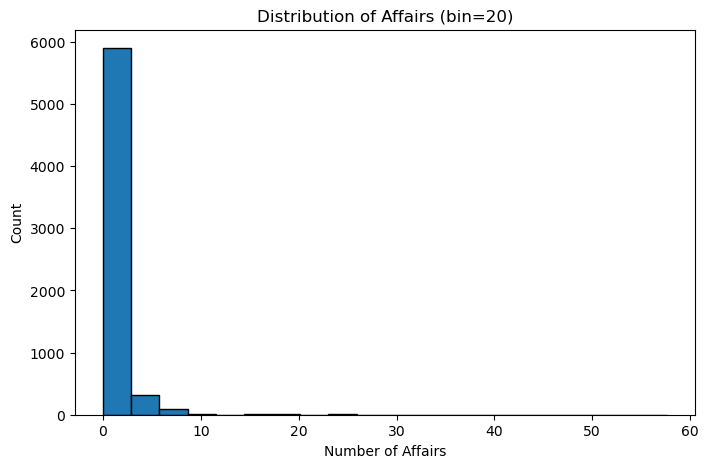

In [10]:

# 6. 타겟변수(affairs)의 분포 시각화
plt.figure(figsize=(8,5))
plt.hist(df['affairs'], bins=20, edgecolor="black")
plt.title("Distribution of Affairs (bin=20)")
plt.xlabel("Number of Affairs")
plt.ylabel("Count")
plt.show()


상관계수 행렬:
                  rate_marriage       age  yrs_married  children  religious  \
rate_marriage         1.000000 -0.111127    -0.128978 -0.129161   0.078794   
age                  -0.111127  1.000000     0.894082  0.673902   0.136598   
yrs_married          -0.128978  0.894082     1.000000  0.772806   0.132683   
children             -0.129161  0.673902     0.772806  1.000000   0.141845   
religious             0.078794  0.136598     0.132683  0.141845   1.000000   
educ                  0.079869  0.027960    -0.109058 -0.141918   0.032245   
occupation            0.039528  0.106127     0.041782 -0.015068   0.035746   
occupation_husb       0.027745  0.162567     0.128135  0.086660   0.004061   
affairs              -0.178068 -0.089964    -0.087737 -0.070278  -0.125933   

                     educ  occupation  occupation_husb   affairs  
rate_marriage    0.079869    0.039528         0.027745 -0.178068  
age              0.027960    0.106127         0.162567 -0.089964  
yrs_mar

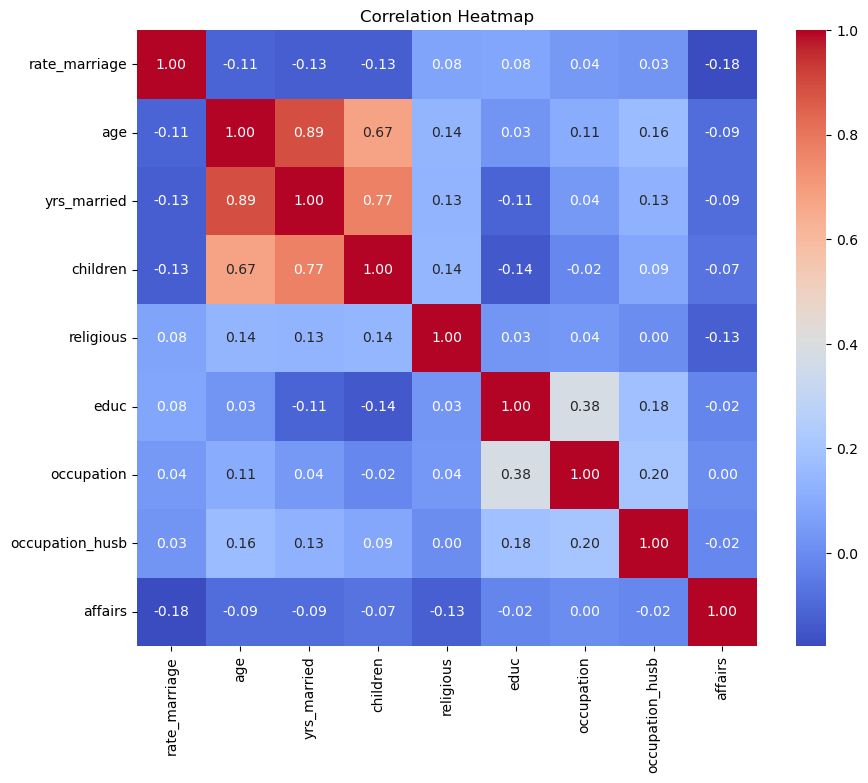

In [11]:

# 7. 상관계수 행렬 (수치형 변수만)
corr_matrix = df.corr(numeric_only=True)
print("\n상관계수 행렬:\n", corr_matrix)

# 8. 상관관계 히트맵 시각화
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# 9-1 affairs 와 features 사이 relation (산포도, regression)
for cols in num_cols:
    # (3) 연속형 관계(산점도 + 회귀선)
    #    과도한 겹침을 줄이기 위해 투명도/샘플링/상한 클리핑 사용
    #    (상한: 99퍼센타일로 x/ y 축 스케일 안정화)
    x_cap = np.nanpercentile(df["affairs"], 99)
    y_cap = np.nanpercentile(df[col], 99)

    # 필요하면 다운샘플링(표본 수가 너무 많을 때)
    plot_df = df[["affairs", col]].dropna()
    if len(plot_df) > 8000:
        plot_df = plot_df.sample(8000, random_state=42)

    plt.figure(figsize=(6,4))
    sns.scatterplot(x="affairs", y=col, data=plot_df, alpha=0.35, s=20, edgecolor=None)
    sns.regplot(x="affairs", y=col, data=plot_df, scatter=False, color="crimson", line_kws={"lw":2})
    plt.title(f"{col} vs Affairs (continuous)")
    plt.xlim(left=0, right=x_cap)
    plt.ylim(bottom=min(plot_df[col].min(), 0), top=y_cap)
    plt.tight_layout()
    plt.show()


NameError: name 'num_cols' is not defined

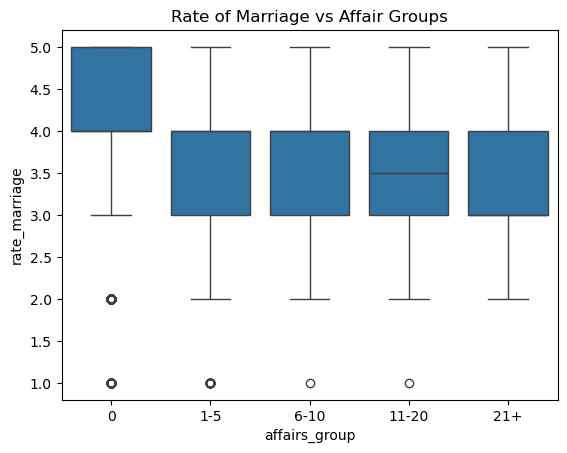

In [ ]:
#9-2 affairs 와 features 사이 relation (히스토그램)

bins = [0, 1, 5, 10, 20, df["affairs"].max()]
labels = ["0", "1-5", "6-10", "11-20", "21+"]

df["affairs_group"] = pd.cut(df["affairs"], bins=bins, labels=labels, include_lowest=True)

sns.boxplot(x="affairs_group", y="rate_marriage", data=df)
plt.title("Rate of Marriage vs Affair Groups")
plt.show()

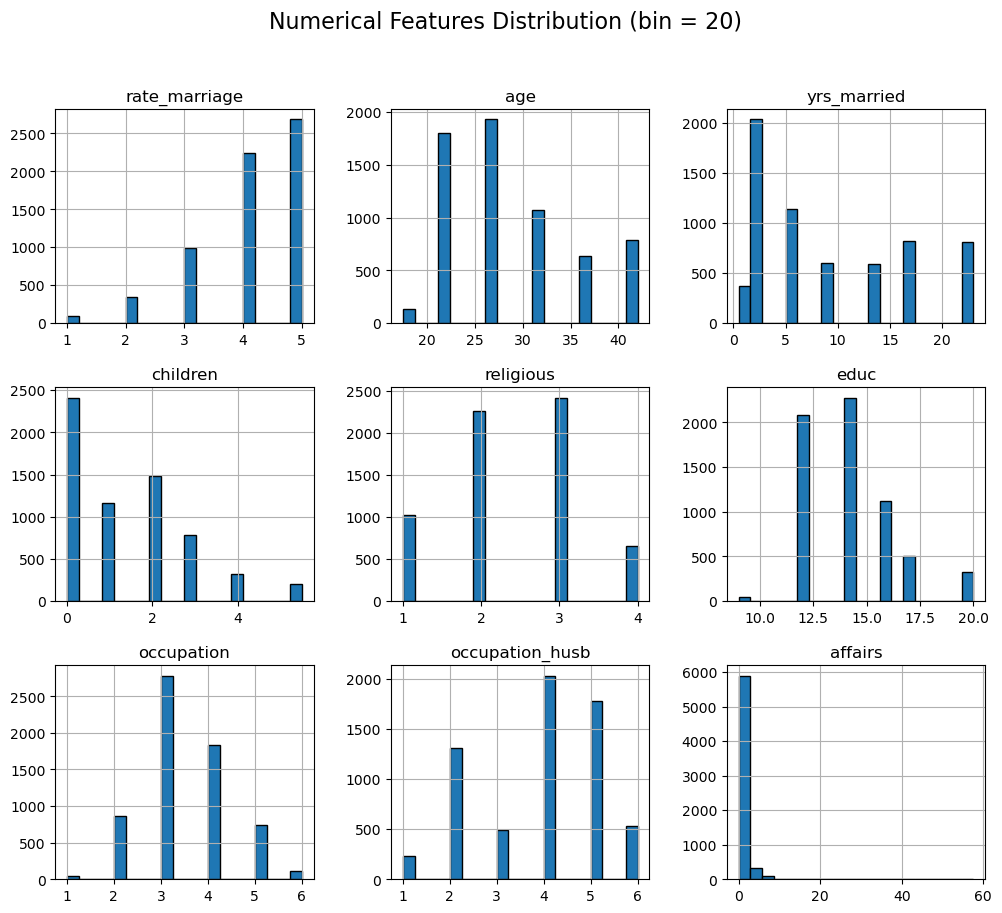

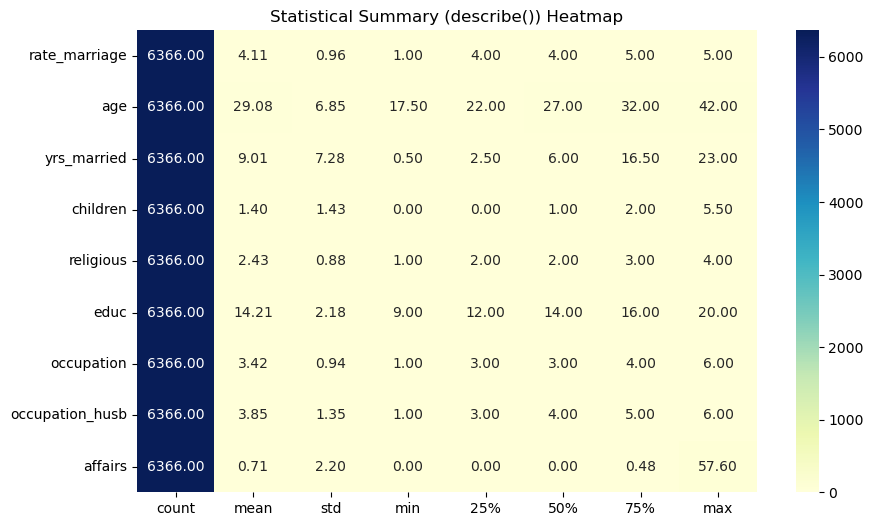

In [ ]:

# 5. 수치형 변수 분포 (히스토그램)
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Numerical Features Distribution (bin = 20)", fontsize=16)
plt.show()

# 6. 범주형 변수 분포 (막대그래프)
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# 7. describe() 결과를 히트맵으로 시각화
desc = df[num_cols].describe().T  # 전치해서 보기 좋게
plt.figure(figsize=(10, 6))
sns.heatmap(desc, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Statistical Summary (describe()) Heatmap")
plt.show()

In [16]:
## 파생변수 추가 
df_derived = df.copy()
df_derived["yrs_per_age"] = df["yrs_married"] / df["age"]
df_derived["rate_x_yrs"] = df["rate_marriage"] * df["yrs_married"]

In [21]:
print(df_derived[["age", "yrs_married", "rate_marriage", "yrs_per_age", "rate_x_yrs"]].head())

df_derived.head(5)

    age  yrs_married  rate_marriage  yrs_per_age  rate_x_yrs
0  32.0          9.0            3.0     0.281250        27.0
1  27.0         13.0            3.0     0.481481        39.0
2  22.0          2.5            4.0     0.113636        10.0
3  37.0         16.5            4.0     0.445946        66.0
4  27.0          9.0            5.0     0.333333        45.0


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,yrs_per_age,rate_x_yrs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,0.281250,27.0
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,0.481481,39.0
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,0.113636,10.0
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,0.445946,66.0
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,0.333333,45.0



상관계수 행렬:
                  rate_marriage       age  yrs_married  children  religious  \
rate_marriage         1.000000 -0.111127    -0.128978 -0.129161   0.078794   
age                  -0.111127  1.000000     0.894082  0.673902   0.136598   
yrs_married          -0.128978  0.894082     1.000000  0.772806   0.132683   
children             -0.129161  0.673902     0.772806  1.000000   0.141845   
religious             0.078794  0.136598     0.132683  0.141845   1.000000   
educ                  0.079869  0.027960    -0.109058 -0.141918   0.032245   
occupation            0.039528  0.106127     0.041782 -0.015068   0.035746   
occupation_husb       0.027745  0.162567     0.128135  0.086660   0.004061   
affairs              -0.178068 -0.089964    -0.087737 -0.070278  -0.125933   
yrs_per_age          -0.139637  0.800493     0.971583  0.772046   0.116867   
rate_x_yrs            0.193385  0.822290     0.920049  0.708575   0.152240   

                     educ  occupation  occupation_hu

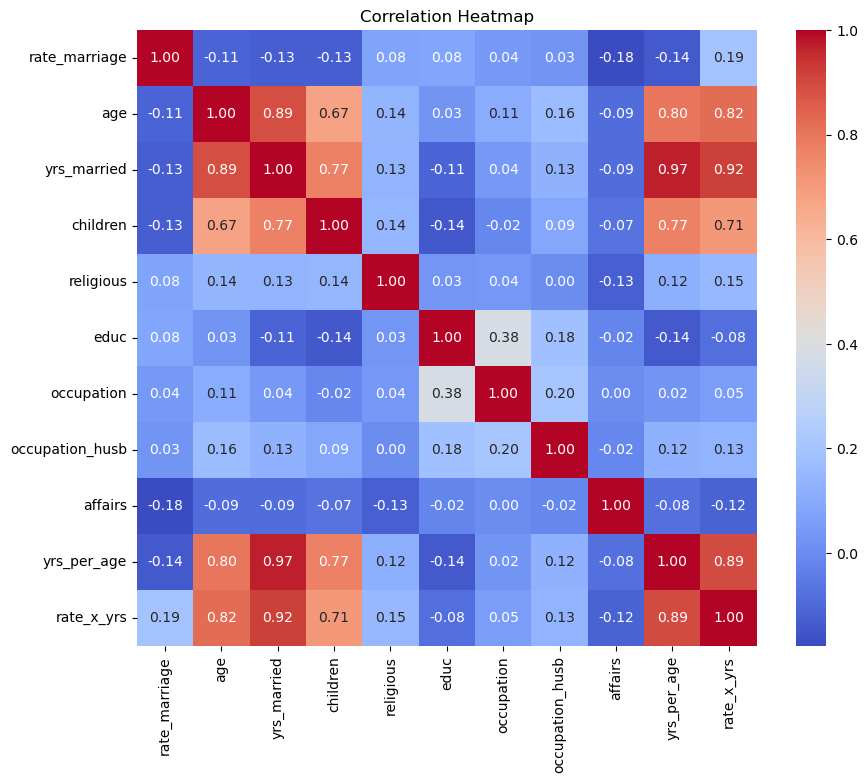

In [22]:
# 7. 상관계수 행렬 (수치형 변수만)
corr_matrix = df_derived.corr(numeric_only=True)
print("\n상관계수 행렬:\n", corr_matrix)

# 8. 상관관계 히트맵 시각화
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=["affairs"])  # target 제외
X_const = add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

print(vif)

          Variable        VIF
0            const  97.977265
1    rate_marriage   1.034798
2              age   5.454116
3      yrs_married   7.142949
4         children   2.528972
5        religious   1.036906
6             educ   1.296242
7       occupation   1.206863
8  occupation_husb   1.082876
